# Week 3 — Information Timing, Technical Indicators, Features, and Signals

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/03/week3_main.ipynb)

The repository is currently private. The direct Colab link requires permission to the repository and GitHub authorization in Colab. If the link does not open, download `week3_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 3 lesson. It integrates preparation, information records, technical indicators, financially motivated features, leakage checks, publication-time alignment, executable examples, discussion questions, independent practice, troubleshooting, extensions, and sources in one document.

## Core financial question

How can a financial idea be converted into a feature and then a signal while using only information that was available at the stated decision time?

Week 2 established auditable prices, returns, dates, fields, and units. Week 3 adds information availability, technical indicators, features, and signals. Week 4 will convert the signal into a position, trade, return, and wealth ledger. Week 3 deliberately stops before that accounting: it does not report strategy returns, costs, performance measures, or profitability.

All required calculations use fixed artificial data. The examples demonstrate timing, calculation, and audit mechanics only. They do not document a real provider, establish predictability, or recommend a trade.

## Observable outcome

After completing Week 3, you will produce a reproducible notebook that states a financial hypothesis, documents the information time of every input, calculates trailing technical indicators and features, rejects deliberately invalid candidates, aligns separately published data by publication time, and creates a simple signal without treating it as an executed position.

## Learning objectives

After completing Week 3, you should be able to:

- distinguish observation, publication, signal, decision, execution, and evaluation times;
- translate a financial hypothesis into a measurable feature with a stated lookback, unit, first valid date, and contradiction condition;
- calculate and interpret simple moving averages, exponentially weighted means, moving-average gaps, trailing momentum, rolling volatility, range, and volume-change features;
- identify future values, negative shifts, centered windows, full-sample preprocessing, and historical revisions that can introduce unavailable information;
- align separately published variables to decision times using only releases already available; and
- convert a stated feature rule into a signal while preserving missing history and postponing performance claims.

## Before you begin

Complete Week 2 or be able to calculate returns from a positive, sorted, unique price series. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, and `matplotlib`. No internet connection or online market data is required.

Each issue follows the same sequence: read the financial problem, preserve a prediction, run the complete example, inspect the table or figure, answer four discussion questions, save the requested evidence, and use the first diagnostic action if the result differs.

# Navigation through the twenty issues

The twenty issues form five connected sections. Teaching examples sometimes isolate one calculation, but an actual feature workflow must preserve every earlier information and data decision.

| Section | Issues | Main question | Evidence carried forward |
|---|---:|---|---|
| Information boundaries and financial questions | 1–4 | When is each value usable, and what claim is the feature intended to examine? | Ordered times, information record, hypothesis, and lookback boundary |
| Technical indicators and features | 5–11 | What does each trailing calculation measure, and which inputs, units, and first valid dates does it require? | Audited artificial data and seven documented feature calculations |
| Targets and leakage checks | 12–16 | Which columns are future outcomes or otherwise unavailable at the decision time? | Separated target, lag audit, window audit, preprocessing parameters, and missing-history policy |
| Separately published and revised data | 17–18 | Which release version was available for each historical decision? | Backward publication-time alignment and release-specific values |
| Signals and preparation for Week 4 | 19–20 | What exactly does the rule output, and what remains untested before backtesting? | Missing-preserving signal, audit table, and claim boundary |

Apply the dependency in this order:

```text
documented financial data and return intervals
        ↓
observation and publication availability
        ↓
financial hypothesis and trailing feature
        ↓
target and leakage audit
        ↓
signal with a stated decision boundary
        ↓
Week 4 position and backtest ledger
```

A later model or backtest cannot repair an earlier timing error. If a source value, release time, lookback, or missing-history rule remains unresolved, return to that decision before interpreting the signal.

# Preparation and required records

## Working rules

- Every date, time, market label, asset, price, return, and volume in the required examples is artificial.
- A feature may use only values available by its stated signal time.
- A target may describe a later outcome, but it must never be included among the time-$t$ features.
- Missing feature history remains missing until the required source observations exist; it is not automatically a zero signal.
- An indicator or signal is a calculated object, not evidence of a fill, return, profit, or future performance.
- The common real dataset and its publication history remain pending. Do not substitute an online dataset into the required work unless the instructor publishes those decisions.

## Record of when information becomes available

Complete one record for every feature or separately published variable used in your work.

```text
Variable or feature:
Financial meaning:
Source observation and field:
Observation time:
Period represented, when relevant:
Publication time:
Transformation and lookback:
Last source value used:
Feature or signal time:
Decision time:
Earliest permitted execution time:
First eligible evaluation return:
Join key and direction, when applicable:
Preprocessing fit period, when applicable:
Leakage checks performed:
Claim supported:
Claim not supported:
Unresolved information:
```

## Required checks

Preserve the relevant results rather than writing only that a check passed:

- input dates are parsed, unique, and sorted;
- prices used in ratios are finite and positive;
- every rolling calculation states its source column, lookback, endpoint, `min_periods`, and first valid date;
- feature units and scale are recorded;
- negative shifts, centered windows, future targets, and full-sample preprocessing are excluded from time-$t$ features;
- publication-time joins are sorted and never match a release later than the decision;
- initial unavailable features and signals remain missing under the stated rule; and
- no signal is described as a position or assigned a return in Week 3.

In [1]:
from importlib.metadata import version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 140)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8


## Issue 1 — When does information become usable?


An economic event, a published value, a calculated signal, a recorded decision, an execution assumption, and an evaluated return are different events. Their order determines which outcome can legitimately be associated with a decision. Equal timestamps are possible only when the source and workflow actually support that convention.

The artificial example uses an end-of-session price. It is observed at 16:00, released to the class dataset at 16:01, used in a feature at 16:05, and accepted by a rule at 16:06. Execution is not permitted until the next boundary. A return that ended at 16:00 cannot be earned by this later decision.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [2]:
timeline = pd.DataFrame(
    {
        "Event": [
            "Observation", "Publication", "Signal calculation",
            "Decision", "Earliest execution", "Evaluation endpoint",
        ],
        "Timestamp": pd.to_datetime(
            [
                "2026-03-02 16:00", "2026-03-02 16:01",
                "2026-03-02 16:05", "2026-03-02 16:06",
                "2026-03-03 09:00", "2026-03-03 16:00",
            ]
        ),
        "Meaning": [
            "Artificial close occurs",
            "Value becomes available in the stated dataset",
            "All trailing inputs are combined",
            "Rule output is accepted",
            "A transaction may occur under the stated assumption",
            "First eligible holding result can be observed",
        ],
    }
)
timeline["Minutes_after_observation"] = (
    timeline["Timestamp"] - timeline["Timestamp"].iloc[0]
).dt.total_seconds() / 60
strictly_ordered = timeline["Timestamp"].diff().dropna().gt(pd.Timedelta(0)).all()
display(timeline)
print("Strictly ordered timestamps:", strictly_ordered)
assert strictly_ordered
assert timeline.loc[4, "Timestamp"] > timeline.loc[3, "Timestamp"]

,Event,Timestamp,Meaning,Minutes_after_observation
0,Observation,2026-03-02 16:00:00,Artificial close occurs,0.0
1,Publication,2026-03-02 16:01:00,Value becomes available in the stated dataset,1.0
2,Signal calculation,2026-03-02 16:05:00,All trailing inputs are combined,5.0
3,Decision,2026-03-02 16:06:00,Rule output is accepted,6.0
4,Earliest execution,2026-03-03 09:00:00,A transaction may occur under the stated assum...,1020.0
5,Evaluation endpoint,2026-03-03 16:00:00,First eligible holding result can be observed,1440.0


Strictly ordered timestamps: True


### Interpret the output


The table preserves six distinct events and their order. The first eligible evaluation endpoint occurs only after the stated execution boundary. The exact timestamps are artificial assumptions; the transferable requirement is to document and enforce the actual order for the chosen source and trading design.


### Discussion questions

1. Which pair of times could be equal under a carefully documented real workflow?
2. Why is the observation time not automatically the publication time?
3. Which return interval ended before the signal existed?
4. What additional evidence would be needed to claim that the execution time is realistic?

### Evidence to preserve

Save the table, the ordered-time assertion, your prediction, and one sentence identifying the first eligible evaluation interval.

### First diagnostic action

When the order is unclear, identify the latest source value needed and locate the first timestamp at which that value was actually available.

## Issue 2 — What must an information record preserve?


A column name does not identify its information boundary. A usable record links each variable to its financial meaning, source observation, publication time, transformation, latest included value, and earliest signal time. `pending` is more accurate than an invented time when the source does not disclose one.

The record below distinguishes an artificial closing price, a five-session momentum feature, and a separately published indicator. The feature cannot be available before all of its source prices are available. The separately published value is governed by its release time rather than the period it describes.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [3]:
information_record = pd.DataFrame(
    [
        {
            "Variable": "close_t",
            "Financial_meaning": "Artificial session closing price",
            "Period_represented": "Artificial session t",
            "Observation_time": "16:00 at session t",
            "Latest_source_value": "Close at t",
            "Publication_time": "16:01 after session t",
            "Earliest_feature_time": "16:01 after session t",
            "Unresolved": "Real provider timestamp and timezone",
        },
        {
            "Variable": "mom_5_t",
            "Financial_meaning": "Five-session trailing price change",
            "Period_represented": "t-5 through t",
            "Observation_time": "Each included artificial close",
            "Latest_source_value": "Close at t",
            "Publication_time": "Depends on all six source prices",
            "Earliest_feature_time": "After Close at t is published",
            "Unresolved": "Real asset and field definition",
        },
        {
            "Variable": "published_indicator",
            "Financial_meaning": "Artificial value for an earlier period",
            "Period_represented": "Earlier artificial period",
            "Observation_time": "Earlier period; not the availability time",
            "Latest_source_value": "Released value and release version",
            "Publication_time": "Stated release timestamp",
            "Earliest_feature_time": "At or after release timestamp",
            "Unresolved": "Provider revision history",
        },
    ]
).set_index("Variable")
display(information_record)
print("Rows with unresolved information:", information_record["Unresolved"].notna().sum())
assert information_record.index.is_unique
assert information_record["Unresolved"].notna().all()

,Financial_meaning,Period_represented,Observation_time,Latest_source_value,Publication_time,Earliest_feature_time,Unresolved
Variable,,,,,,,
close_t,Artificial session closing price,Artificial session t,16:00 at session t,Close at t,16:01 after session t,16:01 after session t,Real provider timestamp and timezone
mom_5_t,Five-session trailing price change,t-5 through t,Each included artificial close,Close at t,Depends on all six source prices,After Close at t is published,Real asset and field definition
published_indicator,Artificial value for an earlier period,Earlier artificial period,Earlier period; not the availability time,Released value and release version,Stated release timestamp,At or after release timestamp,Provider revision history


Rows with unresolved information: 3


### Interpret the output


Every row contains a financial interpretation and an availability statement, yet every row also retains an unresolved real-data question. The record supports an audit of the artificial workflow; it does not establish the timing conventions of a future provider.


### Discussion questions

1. Which fields describe economic meaning rather than availability?
2. Why does a feature inherit the latest availability time among all its inputs?
3. When is `pending` preferable to assuming zero publication delay?
4. Which record fields would change if a provider later revised a published value?

### Evidence to preserve

Save the completed record for one feature you plan to use, including every unresolved source field.

### First diagnostic action

When a feature time cannot be stated, list all source observations and take the latest verified availability time rather than the latest period label.

## Issue 3 — Does the feature begin with a financial question?


A technical indicator is a numerical summary of market observations. It becomes a feature when it is used as an input to a stated analysis. Neither label establishes predictive value. A financially interpretable feature should be connected to a question that can be contradicted by evidence.

The classroom question below asks whether positive five-session momentum is associated with a different mean next-session return in this artificial sample. It does not say that momentum will be profitable, and it does not reproduce the formation or holding periods studied in the cited momentum literature.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [4]:
hypothesis_record = pd.DataFrame(
    {
        "Recorded_statement": [
            "Artificial observations with positive five-session momentum may have a different mean next-session return from nonpositive observations.",
            "Five-session price change ending at t",
            "Close[t] / Close[t-5] - 1",
            "Close at t",
            "Next-session return after the stated future execution boundary",
            "No material difference under the prespecified comparison",
            "Profitability after costs or future market performance",
        ]
    },
    index=[
        "Financial question", "Observable variable", "Formula",
        "Latest source input", "Outcome for later evaluation",
        "Result that could contradict the question", "Claim not established",
    ],
)
display(hypothesis_record)
print("The record separates the feature from its later outcome and unsupported claim.")
assert "Profitability" in hypothesis_record.loc["Claim not established", "Recorded_statement"]

,Recorded_statement
Financial question,Artificial observations with positive five-ses...
Observable variable,Five-session price change ending at t
Formula,Close[t] / Close[t-5] - 1
Latest source input,Close at t
Outcome for later evaluation,Next-session return after the stated future ex...
Result that could contradict the question,No material difference under the prespecified ...
Claim not established,Profitability after costs or future market per...


The record separates the feature from its later outcome and unsupported claim.


### Interpret the output


The record states the feature, the later outcome, and a result that could contradict the proposed relationship. This makes the question testable without defining success as profit. The five-session artificial definition is a teaching choice and must not be attributed to a paper that studies different assets and horizons.


### Discussion questions

1. What observation would contradict the proposed association?
2. Why is future profitability not a feature definition?
3. How would changing the holding horizon change the research question?
4. What evidence would be needed before transferring the question to a real market?

### Evidence to preserve

Save a completed hypothesis record whose feature, outcome horizon, contradiction condition, and unsupported claim are all explicit.

### First diagnostic action

When a hypothesis cannot be contradicted, rewrite the proposed relationship before calculating an indicator.

## Issue 4 — Where does a trailing window begin and end?


A lookback of $k$ price changes requires $k+1$ price observations. A rolling statistic over $k$ nonmissing returns requires $k$ returns, so it generally begins one row later than a $k$-price rolling mean. The first valid date is part of the feature definition, not a cosmetic missing-value problem.

The small table uses three-session examples so every required source row can be inspected. All windows end at the current row; no future row is included.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [5]:
boundary_price = pd.Series(
    [100.0, 102.0, 101.0, 104.0, 103.0, 105.0, 108.0, 107.0],
    index=pd.date_range("2026-01-05", periods=8, freq="D"),
    name="Artificial_Close",
)
boundary_table = boundary_price.to_frame()
boundary_table["ret_1"] = boundary_price.pct_change(fill_method=None)
boundary_table["sma_3"] = boundary_price.rolling(3, min_periods=3).mean()
boundary_table["mom_3"] = boundary_price / boundary_price.shift(3) - 1
boundary_table["vol_3"] = boundary_table["ret_1"].rolling(3, min_periods=3).std(ddof=1)
display(boundary_table.round(6))

first_valid = boundary_table.apply(lambda column: column.first_valid_index()).to_frame("First_valid_date")
first_valid["Row_position"] = [boundary_table.index.get_loc(date) for date in first_valid["First_valid_date"]]
display(first_valid)

assert first_valid.loc["sma_3", "Row_position"] == 2
assert first_valid.loc["mom_3", "Row_position"] == 3
assert first_valid.loc["vol_3", "Row_position"] == 3

,Artificial_Close,ret_1,sma_3,mom_3,vol_3
2026-01-05,100.0,NaN,NaN,NaN,NaN
2026-01-06,102.0,0.020000,NaN,NaN,NaN
2026-01-07,101.0,-0.009804,101.000000,NaN,NaN
2026-01-08,104.0,0.029703,102.333333,0.040000,0.020588
2026-01-09,103.0,-0.009615,102.666667,0.009804,0.022755
2026-01-10,105.0,0.019417,104.000000,0.039604,0.020390
2026-01-11,108.0,0.028571,105.333333,0.038462,0.019937
2026-01-12,107.0,-0.009259,106.666667,0.038835,0.019737


,First_valid_date,Row_position
Artificial_Close,2026-01-05,0
ret_1,2026-01-06,1
sma_3,2026-01-07,2
mom_3,2026-01-08,3
vol_3,2026-01-08,3


### Interpret the output


The three-price moving average begins at row position 2. Three-session momentum needs four price endpoints, and three-return volatility needs three nonmissing returns, so both begin at position 3. Filling these earlier cells would invent source history rather than recover an observation.


### Discussion questions

1. Why does three-session momentum need four prices?
2. Why do the moving average and volatility start on different rows?
3. What does `min_periods=3` communicate to the reader?
4. How would a missing price inside the window affect the first later valid result?

### Evidence to preserve

Save the source table, first-valid-date table, row counts for each formula, and your revised prediction.

### First diagnostic action

When the first valid date is unexpected, list every price or return required for the first candidate calculation before changing `min_periods`.

## Issue 5 — Is the feature input ready for calculation?


Feature engineering cannot repair an unidentified or invalid input. Before calculating indicators, verify the source record, timestamp convention, field, unit, order, uniqueness, positivity, and the return interval inherited from Week 2.

The following fixed-seed artificial OHLCV table supplies a common input for Issues 5–20. Its business-day labels are not an exchange calendar, and its price and volume paths are not market evidence.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Open,High,Low,Close,Volume,ret_1d
Artificial_Date,,,,,,
2024-01-02,99.2182,99.3885,98.8768,99.0726,1104025,NaN
2024-01-03,98.8926,100.0712,98.4992,99.3789,865579,0.0031
2024-01-04,96.7239,97.5407,96.2691,97.1624,1014632,-0.0223
2024-01-05,98.5066,99.0657,97.7379,98.8233,1495734,0.0171


,Open,High,Low,Close,Volume,ret_1d
Artificial_Date,,,,,,
2024-05-01,114.3372,115.2103,113.0150,113.9313,1404278,-0.0077
2024-05-02,113.5651,114.2414,112.4886,113.6864,949925,-0.0021
2024-05-03,112.5624,113.2741,112.0520,112.5502,1076456,-0.0100
2024-05-06,114.0370,114.1615,112.4861,113.4914,1408686,0.0084


,Audit result
Check,
rows,90
unique_index,True
sorted_index,True
missing_price_values,0
nonfinite_price_values,0
nonpositive_price_values,0
ohlc_range_violations,0
negative_volume_values,0
missing_first_returns,1


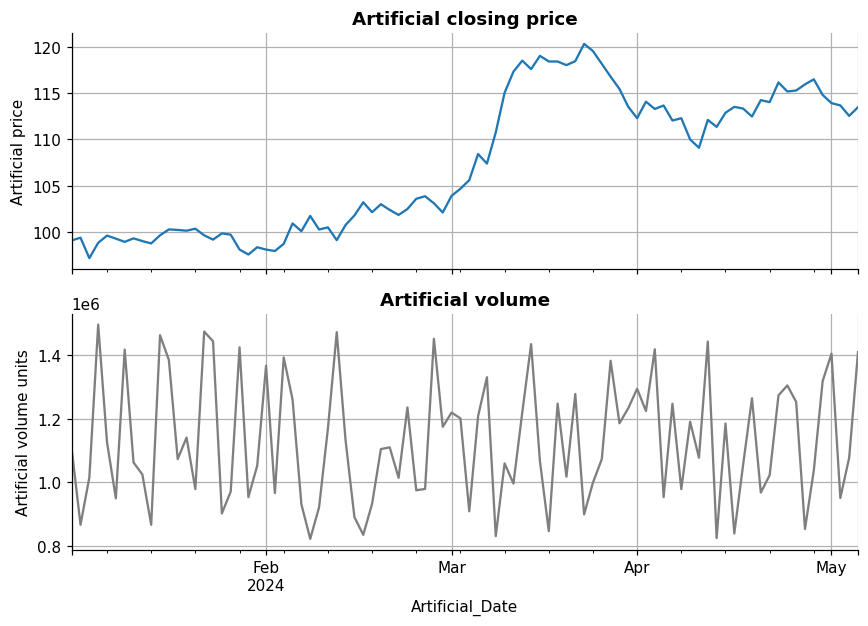

In [6]:
rng = np.random.default_rng(2026)
feature_dates = pd.bdate_range("2024-01-02", periods=90)
artificial_log_return = rng.normal(0.0002, 0.012, len(feature_dates))
artificial_close = 100 * np.exp(np.cumsum(artificial_log_return))
artificial_open = artificial_close * (1 + rng.normal(0, 0.0025, len(feature_dates)))
artificial_high = np.maximum(artificial_open, artificial_close) * (1 + rng.uniform(0.001, 0.010, len(feature_dates)))
artificial_low = np.minimum(artificial_open, artificial_close) * (1 - rng.uniform(0.001, 0.010, len(feature_dates)))
artificial_volume = rng.integers(800_000, 1_500_000, len(feature_dates))

features = pd.DataFrame(
    {
        "Open": artificial_open,
        "High": artificial_high,
        "Low": artificial_low,
        "Close": artificial_close,
        "Volume": artificial_volume,
    },
    index=feature_dates,
)
features.index.name = "Artificial_Date"
features["ret_1d"] = features["Close"].pct_change(fill_method=None)

input_audit = pd.Series(
    {
        "rows": len(features),
        "unique_index": features.index.is_unique,
        "sorted_index": features.index.is_monotonic_increasing,
        "missing_price_values": int(features[["Open", "High", "Low", "Close"]].isna().sum().sum()),
        "nonfinite_price_values": int((~np.isfinite(features[["Open", "High", "Low", "Close"]])).sum().sum()),
        "nonpositive_price_values": int(features[["Open", "High", "Low", "Close"]].le(0).sum().sum()),
        "ohlc_range_violations": int((
            (features["High"] < features[["Open", "Close"]].max(axis=1))
            | (features["Low"] > features[["Open", "Close"]].min(axis=1))
            | (features["High"] < features["Low"])
        ).sum()),
        "negative_volume_values": int(features["Volume"].lt(0).sum()),
        "missing_first_returns": int(features["ret_1d"].isna().sum()),
    },
    name="Audit result",
)
display(features.head(4).round(4))
display(features.tail(4).round(4))
display(input_audit.rename_axis("Check").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.8), sharex=True)
features["Close"].plot(ax=axes[0], color="tab:blue")
axes[0].set_ylabel("Artificial price")
axes[0].set_title("Artificial closing price")
features["Volume"].plot(ax=axes[1], color="tab:grey")
axes[1].set_ylabel("Artificial volume units")
axes[1].set_title("Artificial volume")
plt.tight_layout()
plt.show()

assert input_audit["rows"] == 90
assert input_audit["unique_index"] and input_audit["sorted_index"]
assert input_audit["missing_price_values"] == 0
assert input_audit["nonfinite_price_values"] == 0
assert input_audit["nonpositive_price_values"] == 0
assert input_audit["ohlc_range_violations"] == 0
assert input_audit["missing_first_returns"] == 1

### Interpret the output


The table contains 90 ordered artificial rows, positive finite prices, nonnegative volume, and one expected missing first return. The figure makes the price and volume paths visible but does not make either series a real observation. All later interpretations inherit this artificial-data boundary.


### Discussion questions

1. Which Week 2 checks are reused before any feature is calculated?
2. Why is a pandas business-day index not an exchange calendar?
3. What provider facts remain absent even though all assertions pass?
4. Which later features require the return column rather than the price level?

### Evidence to preserve

Save the artificial source statement, first and last rows, audit table, figure, environment versions, and every unresolved real-data field.

### First diagnostic action

When an input assertion fails, preserve the original row and repair the data or definition before adding a rolling calculation.

## Issue 6 — What does a simple moving average retain and omit?


A simple moving average over $k$ observations assigns equal weight to the $k$ included price levels and no weight to earlier values. It smooths the observed price path but does not by itself measure a return, predict direction, or establish a trend that will continue.

The five- and twenty-session means below use trailing windows ending at the current artificial close. `min_periods` equals the window size so the notebook does not create partially defined early values.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Close,sma_5,sma_20
Artificial_Date,,,
2024-01-23,99.6289,100.1186,NaN
2024-01-24,99.1672,99.8977,NaN
2024-01-25,99.8418,99.8231,NaN
2024-01-26,99.7055,99.7378,NaN
2024-01-29,98.0941,99.2875,99.3171
2024-01-30,97.5534,98.8724,99.2411
2024-01-31,98.3448,98.7079,99.1894
2024-02-01,98.0907,98.3577,99.2359
2024-02-02,97.9354,98.0037,99.1915


,First_valid_date,Required_prices,Initial_missing_values,Unit
sma_5,2024-01-08,5,4,Artificial price units
sma_20,2024-01-29,20,19,Artificial price units


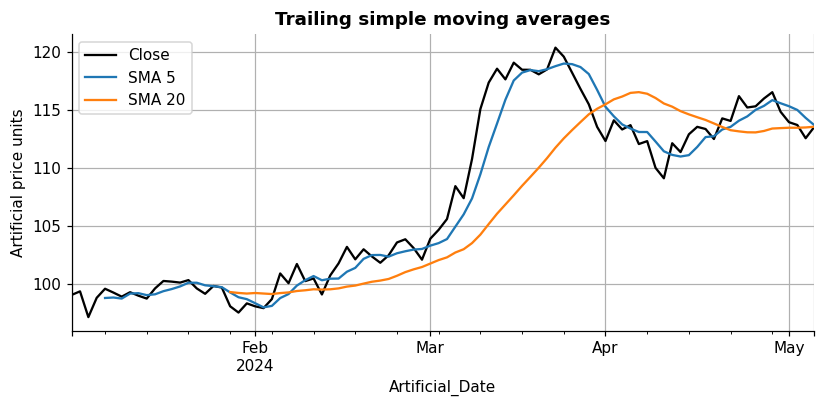

In [7]:
features["sma_5"] = features["Close"].rolling(5, min_periods=5).mean()
features["sma_20"] = features["Close"].rolling(20, min_periods=20).mean()

sma_first_valid = pd.DataFrame(
    {
        "First_valid_date": [features["sma_5"].first_valid_index(), features["sma_20"].first_valid_index()],
        "Required_prices": [5, 20],
        "Initial_missing_values": [features["sma_5"].isna().sum(), features["sma_20"].isna().sum()],
        "Unit": ["Artificial price units", "Artificial price units"],
    },
    index=["sma_5", "sma_20"],
)
display(features[["Close", "sma_5", "sma_20"]].iloc[15:24].round(4))
display(sma_first_valid)

ax = features[["Close", "sma_5", "sma_20"]].plot(color=["black", "tab:blue", "tab:orange"])
ax.set_ylabel("Artificial price units")
ax.set_title("Trailing simple moving averages")
ax.legend(["Close", "SMA 5", "SMA 20"])
plt.tight_layout()
plt.show()

assert features["sma_5"].isna().sum() == 4
assert features["sma_20"].isna().sum() == 19

### Interpret the output


The five-session average begins after five prices; the twenty-session average begins after twenty. Both retain the same price unit as the input. The shorter line responds more quickly in this fixed path, but the figure does not establish which window predicts a later outcome.


### Discussion questions

1. Which exact price rows enter the first five-session average?
2. Why is a moving average a price-level feature rather than a return?
3. What changes when a window is shortened?
4. Why should the window not be chosen by inspecting final strategy performance in Week 3?

### Evidence to preserve

Save the formula, window sizes, first valid dates, missing counts, table, figure, and unit statement.

### First diagnostic action

When the moving average begins too early, inspect `min_periods`, fills, and whether the calculation used a trailing rather than centered window.

## Issue 7 — How does an exponentially weighted mean differ?


An exponentially weighted mean assigns larger weights to more recent observations under a specified decay parameter. The `span` does not mean that observations older than the span receive exactly zero weight. Initialization and `adjust` settings are part of the calculation and must be recorded.

The example uses `span=5`, `adjust=False`, and `min_periods=5`. It compares the result with the five-session simple moving average without asserting that either measure is a better predictor.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Setting,Value
0,span,5
1,adjust,False
2,min_periods,5
3,input,Close through t
4,unit,Artificial price units
5,first valid date,2024-01-08 00:00:00


,Close,sma_5,ewm_5
Artificial_Date,,,
2024-01-02,99.0726,NaN,NaN
2024-01-03,99.3789,NaN,NaN
2024-01-04,97.1624,NaN,NaN
2024-01-05,98.8233,NaN,NaN
2024-01-08,99.6030,98.8080,98.9412
2024-01-09,99.2744,98.8484,99.0523
2024-01-10,98.9233,98.7573,99.0093
2024-01-11,99.3045,99.1857,99.1077
2024-01-12,99.0058,99.2222,99.0737


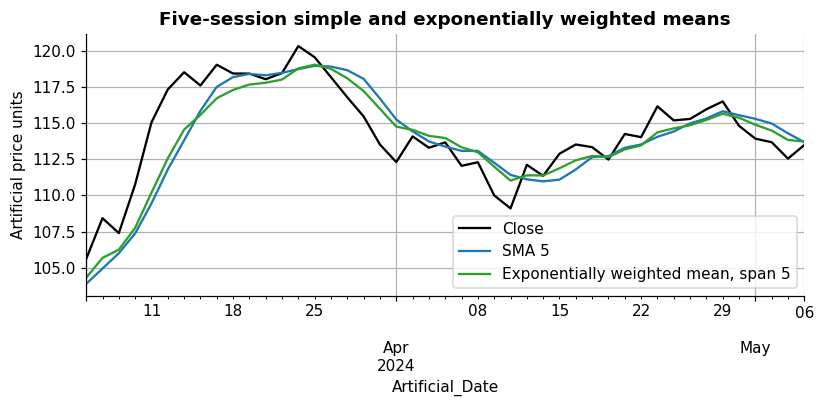

In [8]:
features["ewm_5"] = features["Close"].ewm(
    span=5,
    adjust=False,
    min_periods=5,
).mean()

ewm_record = pd.DataFrame(
    {
        "Setting": ["span", "adjust", "min_periods", "input", "unit", "first valid date"],
        "Value": [5, False, 5, "Close through t", "Artificial price units", features["ewm_5"].first_valid_index()],
    }
)
display(ewm_record)
display(features[["Close", "sma_5", "ewm_5"]].head(10).round(4))

ax = features[["Close", "sma_5", "ewm_5"]].tail(45).plot(color=["black", "tab:blue", "tab:green"])
ax.set_ylabel("Artificial price units")
ax.set_title("Five-session simple and exponentially weighted means")
ax.legend(["Close", "SMA 5", "Exponentially weighted mean, span 5"])
plt.tight_layout()
plt.show()

assert features["ewm_5"].isna().sum() == 4
assert features["ewm_5"].notna().sum() == features["sma_5"].notna().sum()

### Interpret the output


The two smoothed series share their first valid date under the selected `min_periods` rule, but they need not have the same value. The exponentially weighted mean retains influence from earlier observations through its recursion. Its greater response to recent prices in parts of this path is a property of the chosen calculation, not evidence of predictive value.


### Discussion questions

1. Why does `span=5` not create a strict five-row cutoff?
2. Which settings must another student know to reproduce the series?
3. How could different initialization rules alter early values?
4. What later evidence would be needed to compare predictive usefulness?

### Evidence to preserve

Save the complete settings table, first ten rows, comparison figure, and one explanation of how the weighting differs from an SMA.

### First diagnostic action

When exponentially weighted results differ across implementations, compare decay parameterization, `adjust`, `min_periods`, missing-value behavior, and initialization.

## Issue 8 — What does a moving-average gap measure?


A moving-average gap compares a shorter trailing price average with a longer one. Dividing the short mean by the long mean and subtracting one produces a dimensionless relative difference. A positive value means only that the short mean is above the long mean at that endpoint.

The gap cannot be interpreted before both component means exist. Its sign is a feature value, not yet a signal, position, or forecast.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Close,sma_5,sma_20,ma_gap_5_20
Artificial_Date,,,,
2024-01-24,99.167216,99.897716,NaN,NaN
2024-01-25,99.841767,99.823118,NaN,NaN
2024-01-26,99.705497,99.737810,NaN,NaN
2024-01-29,98.094146,99.287509,99.317097,-0.000298
2024-01-30,97.553442,98.872414,99.241140,-0.003715
2024-01-31,98.344814,98.707933,99.189437,-0.004854
2024-02-01,98.090686,98.357717,99.235852,-0.008849
2024-02-02,97.935355,98.003689,99.191457,-0.011975
2024-02-05,98.712310,98.127321,99.146922,-0.010284


,Value
Item,
first_valid_date,2024-01-29 00:00:00
initial_missing_values,19
positive_values,48
nonpositive_values,23
unit,decimal relative difference


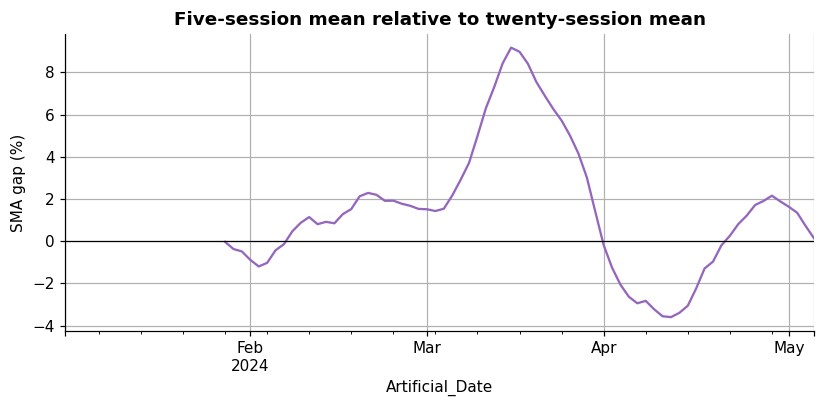

In [9]:
features["ma_gap_5_20"] = features["sma_5"] / features["sma_20"] - 1

gap_table = features[["Close", "sma_5", "sma_20", "ma_gap_5_20"]].iloc[16:25].copy()
display(gap_table.round(6))
gap_summary = pd.Series(
    {
        "first_valid_date": features["ma_gap_5_20"].first_valid_index(),
        "initial_missing_values": int(features["ma_gap_5_20"].isna().sum()),
        "positive_values": int(features["ma_gap_5_20"].gt(0).sum()),
        "nonpositive_values": int(features["ma_gap_5_20"].le(0).sum()),
        "unit": "decimal relative difference",
    },
    name="Value",
)
display(gap_summary.rename_axis("Item").to_frame())

ax = (100 * features["ma_gap_5_20"]).plot(color="tab:purple")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("SMA gap (%)")
ax.set_title("Five-session mean relative to twenty-session mean")
plt.tight_layout()
plt.show()

assert features["ma_gap_5_20"].first_valid_index() == features["sma_20"].first_valid_index()
assert features["ma_gap_5_20"].dropna().shape[0] == len(features) - 19

### Interpret the output


The gap begins when the twenty-session mean becomes available and is expressed as a decimal relative difference. Values above zero describe the ordering of the two averages at the same endpoint. They do not demonstrate that a subsequent return will be positive.


### Discussion questions

1. Why is the gap dimensionless even though both inputs are prices?
2. Which component determines the first valid date?
3. How would a stock split mishandled in the price field affect this feature?
4. What rule would be required before the gap becomes a signal?

### Evidence to preserve

Save the formula, component window records, first valid date, summary table, figure, and a sentence that separates feature meaning from a forecast.

### First diagnostic action

When the gap is unexpectedly missing or extreme, inspect both component averages and their underlying price field before changing the ratio.

## Issue 9 — How is trailing momentum defined here?


The Week 3 momentum feature is the simple price return from the close at $t-k$ to the close at $t$. It uses $k+1$ price endpoints and is available only after the close at $t$ is published. Its unit is a decimal return.

This classroom five- and twenty-session calculation is not the same design as academic momentum studies with different formation periods, holding periods, assets, and portfolio rules. A standard term does not make every implementation equivalent.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Formula,Prices_required,First_valid_date,Unit,Latest_input
mom_5,Close[t] / Close[t-5] - 1,6,2024-01-09,decimal return,Close at t
mom_20,Close[t] / Close[t-20] - 1,21,2024-01-30,decimal return,Close at t


,Close,mom_5,mom_20
Artificial_Date,,,
2024-01-25,99.841767,-0.003722,NaN
2024-01-26,99.705497,-0.004260,NaN
2024-01-29,98.094146,-0.022437,NaN
2024-01-30,97.553442,-0.020832,-0.015334
2024-01-31,98.344814,-0.008293,-0.010405
2024-02-01,98.090686,-0.017539,0.009554
2024-02-02,97.935355,-0.017754,-0.008985
2024-02-05,98.712310,0.006302,-0.008943


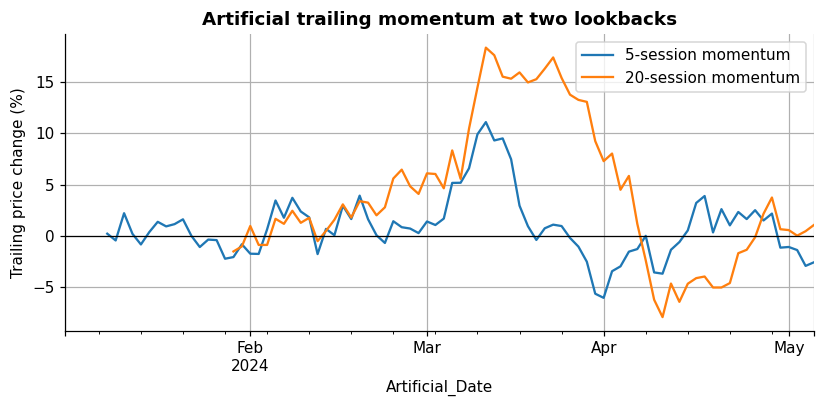

In [10]:
features["mom_5"] = features["Close"] / features["Close"].shift(5) - 1
features["mom_20"] = features["Close"] / features["Close"].shift(20) - 1

momentum_record = pd.DataFrame(
    {
        "Formula": ["Close[t] / Close[t-5] - 1", "Close[t] / Close[t-20] - 1"],
        "Prices_required": [6, 21],
        "First_valid_date": [features["mom_5"].first_valid_index(), features["mom_20"].first_valid_index()],
        "Unit": ["decimal return", "decimal return"],
        "Latest_input": ["Close at t", "Close at t"],
    },
    index=["mom_5", "mom_20"],
)
display(momentum_record)
display(features[["Close", "mom_5", "mom_20"]].iloc[17:25].round(6))

ax = (100 * features[["mom_5", "mom_20"]]).plot(color=["tab:blue", "tab:orange"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Trailing price change (%)")
ax.set_title("Artificial trailing momentum at two lookbacks")
ax.legend(["5-session momentum", "20-session momentum"])
plt.tight_layout()
plt.show()

assert features["mom_5"].isna().sum() == 5
assert features["mom_20"].isna().sum() == 20

### Interpret the output


Five-session momentum begins after six prices, while twenty-session momentum begins after twenty-one. The plot shows that lookback choice changes the feature path and sometimes its sign. That sensitivity is an input to later evaluation, not a reason to retain whichever line looks best after inspecting outcomes.


### Discussion questions

1. Which two endpoints define the value labeled at time $t$?
2. Why do five-session momentum and a five-price moving average start on different rows?
3. How can two momentum lookbacks have opposite signs on the same date?
4. Why must the classroom formula be distinguished from a cited paper's portfolio design?

### Evidence to preserve

Save both formulas, endpoint counts, first valid dates, comparison table, figure, and one limitation of transferring the result.

### First diagnostic action

When momentum disagrees with a hand calculation, display `Close[t]`, `Close[t-k]`, their dates, and the field definition before checking later code.

## Issue 10 — What does rolling volatility measure?


Rolling volatility summarizes dispersion in a trailing return window. The example uses the sample standard deviation of twenty one-session simple returns and multiplies it by $\sqrt{252}$. Both `ddof=1` and 252 are explicit classroom conventions.

Volatility is not a directional forecast. A high value says that the recent artificial returns were more dispersed under this calculation; it does not say the next return will be negative or positive.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Recorded value
Item,
input,twenty one-session simple returns ending at t
lookback,20
ddof,1
annualization_factor,sqrt(252)
unit,annualized decimal volatility under the classr...
first_valid_date,2024-01-30 00:00:00
initial_missing_values,20


,ret_1d,vol_20
Artificial_Date,,
2024-01-25,0.006802,NaN
2024-01-26,-0.001365,NaN
2024-01-29,-0.016161,NaN
2024-01-30,-0.005512,0.138281
2024-01-31,0.008112,0.141241
2024-02-01,-0.002584,0.115913
2024-02-02,-0.001584,0.098033
2024-02-05,0.007933,0.098081


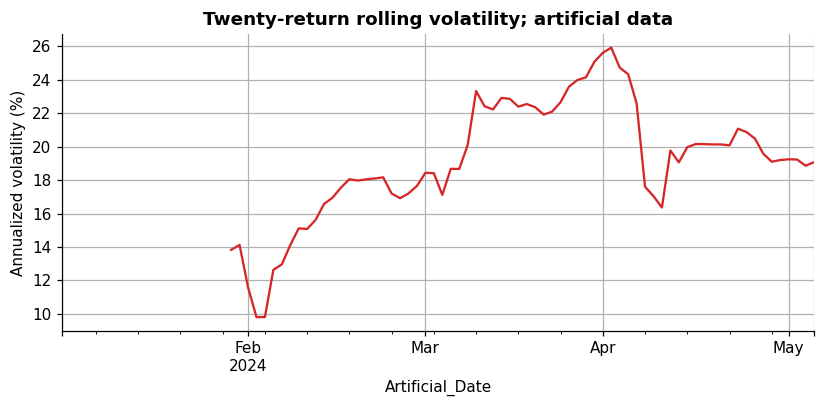

In [11]:
features["vol_20"] = (
    features["ret_1d"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
)

volatility_record = pd.Series(
    {
        "input": "twenty one-session simple returns ending at t",
        "lookback": 20,
        "ddof": 1,
        "annualization_factor": "sqrt(252)",
        "unit": "annualized decimal volatility under the classroom convention",
        "first_valid_date": features["vol_20"].first_valid_index(),
        "initial_missing_values": int(features["vol_20"].isna().sum()),
    },
    name="Recorded value",
)
display(volatility_record.rename_axis("Item").to_frame())
display(features[["ret_1d", "vol_20"]].iloc[17:25].round(6))

ax = (100 * features["vol_20"]).plot(color="tab:red")
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("Twenty-return rolling volatility; artificial data")
plt.tight_layout()
plt.show()

assert features["vol_20"].isna().sum() == 20
assert features["vol_20"].dropna().ge(0).all()

### Interpret the output


The first valid value appears only after twenty nonmissing returns, which requires twenty-one price observations. The annualized percentage in the figure is a reporting conversion of the decimal calculation. The factor 252 does not assert the exact number of sessions in every market or year.


### Discussion questions

1. Why does the first valid volatility date differ from the first five-price mean?
2. What would change if `ddof=0` were used?
3. Why is the annualization factor an assumption rather than a data fact?
4. Why does high trailing volatility not determine the direction of the next return?

### Evidence to preserve

Save the complete calculation record, first valid date, return-and-volatility table, figure, and an explicit annualization limitation.

### First diagnostic action

When volatility begins too early or is implausible, inspect the input return count, missing returns, `ddof`, scale, and annualization conversion.

## Issue 11 — What can price range and volume change describe?


The ratio of the included high minus low to the included close is a dimensionless within-row range measure under the provider's session convention. A one-session volume change compares reported volume units across adjacent rows. Both require provider definitions before real-data interpretation.

Neither feature automatically measures liquidity, investor attention, or uncertainty. Those are possible interpretations that require a stated question and additional evidence.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Formula,Latest_input,First_valid_date,Unit,Provider_fact_still_required
range_pct,(High[t] - Low[t]) / Close[t],"High, Low, and Close at t",2024-01-02,decimal ratio,included session and price construction
volume_change_1d,Volume[t] / Volume[t-1] - 1,Volume at t,2024-01-03,decimal change,reported volume unit and revisions


,High,Low,Close,Volume,range_pct,volume_change_1d
Artificial_Date,,,,,,
2024-01-02,99.388546,98.876809,99.072580,1104025,0.005165,NaN
2024-01-03,100.071214,98.499150,99.378876,865579,0.015819,-0.215979
2024-01-04,97.540701,96.269139,97.162385,1014632,0.013087,0.172200
2024-01-05,99.065687,97.737930,98.823251,1495734,0.013436,0.474164
2024-01-08,100.224553,99.350367,99.603017,1125176,0.008777,-0.247743
2024-01-09,100.293576,99.071404,99.274415,948545,0.012311,-0.156981


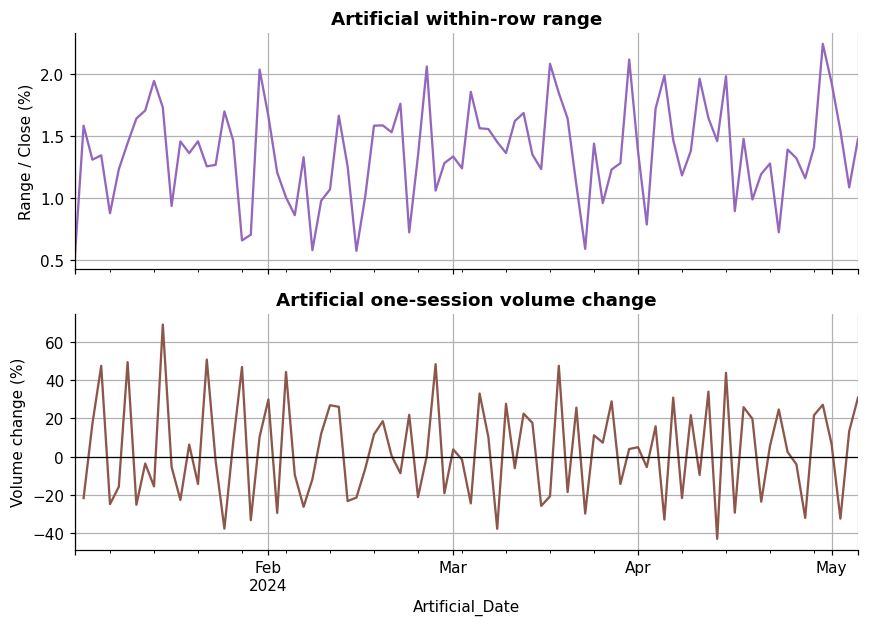

In [12]:
features["range_pct"] = (features["High"] - features["Low"]) / features["Close"]
features["volume_change_1d"] = features["Volume"].pct_change(fill_method=None)

range_volume_record = pd.DataFrame(
    {
        "Formula": ["(High[t] - Low[t]) / Close[t]", "Volume[t] / Volume[t-1] - 1"],
        "Latest_input": ["High, Low, and Close at t", "Volume at t"],
        "First_valid_date": [features["range_pct"].first_valid_index(), features["volume_change_1d"].first_valid_index()],
        "Unit": ["decimal ratio", "decimal change"],
        "Provider_fact_still_required": ["included session and price construction", "reported volume unit and revisions"],
    },
    index=["range_pct", "volume_change_1d"],
)
display(range_volume_record)
display(features[["High", "Low", "Close", "Volume", "range_pct", "volume_change_1d"]].head(6).round(6))

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.8), sharex=True)
(100 * features["range_pct"]).plot(ax=axes[0], color="tab:purple")
axes[0].set_ylabel("Range / Close (%)")
axes[0].set_title("Artificial within-row range")
(100 * features["volume_change_1d"]).plot(ax=axes[1], color="tab:brown")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Volume change (%)")
axes[1].set_title("Artificial one-session volume change")
plt.tight_layout()
plt.show()

assert features["range_pct"].ge(0).all()
assert features["volume_change_1d"].isna().sum() == 1

### Interpret the output


The range feature exists on the first row because all same-row OHLC inputs exist. The volume-change feature needs a preceding row and therefore begins later. The plots describe the artificial inputs only. Interpreting either as a tradable anomaly would exceed the evidence.


### Discussion questions

1. Which provider session definition controls the range numerator?
2. Why does volume change start later than the range feature?
3. What additional evidence would be needed to interpret volume as liquidity?
4. How could a unit change in reported volume create a false feature jump?

### Evidence to preserve

Save both formulas, units, first valid dates, required provider facts, output table, and figure.

### First diagnostic action

When either feature jumps, inspect the original OHLC or volume rows, session definition, unit, and corporate-action or provider-change record.

## Issue 12 — Is a future outcome separated from the features?


A target is the outcome a later model will attempt to predict or explain. A next-session target is not known at time $t$ even though it is stored on row $t$ for later supervised learning. Its row label does not make it a valid time-$t$ input.

The example constructs a future return target and explicitly separates it from the allowed feature list. Week 5 will use chronological training and evaluation; Week 3 only establishes the boundary.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [13]:
features["next_return_target"] = features["ret_1d"].shift(-1)
allowed_feature_columns = [
    "sma_5", "sma_20", "ewm_5", "ma_gap_5_20", "mom_5", "mom_20",
    "vol_20", "range_pct", "volume_change_1d",
]

role_table = pd.DataFrame(
    {
        "Column": allowed_feature_columns + ["next_return_target"],
        "Role": ["feature available after row t under its stated inputs"] * len(allowed_feature_columns) + ["future outcome for later evaluation"],
        "Allowed_as_time_t_feature": [True] * len(allowed_feature_columns) + [False],
    }
).set_index("Column")
display(role_table)
display(features[["ret_1d", "mom_5", "vol_20", "next_return_target"]].tail(6).round(6))

print("Target missing on final row:", pd.isna(features["next_return_target"].iloc[-1]))
assert "next_return_target" not in allowed_feature_columns
assert pd.isna(features["next_return_target"].iloc[-1])
assert np.isclose(features["next_return_target"].iloc[-2], features["ret_1d"].iloc[-1])

,Role,Allowed_as_time_t_feature
Column,,
sma_5,feature available after row t under its stated...,True
sma_20,feature available after row t under its stated...,True
ewm_5,feature available after row t under its stated...,True
ma_gap_5_20,feature available after row t under its stated...,True
mom_5,feature available after row t under its stated...,True
mom_20,feature available after row t under its stated...,True
vol_20,feature available after row t under its stated...,True
range_pct,feature available after row t under its stated...,True
volume_change_1d,feature available after row t under its stated...,True


,ret_1d,mom_5,vol_20,next_return_target
Artificial_Date,,,,
2024-04-29,0.004689,0.021684,0.191029,-0.014499
2024-04-30,-0.014499,-0.011615,0.192027,-0.007739
2024-05-01,-0.007739,-0.010962,0.192474,-0.002149
2024-05-02,-0.002149,-0.013964,0.192339,-0.009994
2024-05-03,-0.009994,-0.029450,0.188643,0.008363
2024-05-06,0.008363,-0.025901,0.190723,NaN


Target missing on final row: True


### Interpret the output


The future outcome on row $t$ equals the realized return on row $t+1$ and is missing on the final row. It is valid as a later target but invalid as a current feature. The allowed list makes that design decision inspectable instead of relying on column naming alone.


### Discussion questions

1. When does `next_return_target[t]` become observable?
2. Why can a future outcome be stored in the same DataFrame without becoming an allowed feature?
3. How would a five-session target change the availability boundary?
4. Which assertion prevents accidental inclusion only indirectly, and what additional code review is still needed?

### Evidence to preserve

Save the target formula, role table, allowed feature list, final-row check, and a sentence stating when the target becomes known.

### First diagnostic action

When model evidence looks implausibly strong later, compare the exact feature list with every target and future-outcome column before tuning the model.

## Issue 13 — What direction does a shift move information?


In pandas, a positive row shift places an earlier value on a later row; a negative shift places a later value on an earlier row. The operation changes alignment, not the economic time at which the original value occurred.

The example makes both directions visible. `shift(-1)` is appropriate for storing a future target but invalid for constructing a time-$t$ feature from that future value.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [14]:
shift_demo = pd.DataFrame(
    {
        "Observed_value": [10.0, 20.0, 30.0, 40.0, 50.0],
    },
    index=pd.date_range("2026-02-02", periods=5, freq="D"),
)
shift_demo["shift_plus_1"] = shift_demo["Observed_value"].shift(1)
shift_demo["shift_minus_1"] = shift_demo["Observed_value"].shift(-1)
shift_demo["plus_1_source_date"] = shift_demo.index.to_series().shift(1)
shift_demo["minus_1_source_date"] = shift_demo.index.to_series().shift(-1)
display(shift_demo)

shift_audit = pd.DataFrame(
    {
        "Expression": ["x.shift(1)", "x.shift(-1)"],
        "Value placed on row t": ["value originally on t-1", "value originally on t+1"],
        "Typical Week 3 role": ["documented lag when required", "future target only; not a time-t feature"],
    }
)
display(shift_audit)

assert shift_demo["shift_plus_1"].iloc[1] == shift_demo["Observed_value"].iloc[0]
assert shift_demo["shift_minus_1"].iloc[0] == shift_demo["Observed_value"].iloc[1]

,Observed_value,shift_plus_1,shift_minus_1,plus_1_source_date,minus_1_source_date
2026-02-02,10.0,NaN,20.0,NaT,2026-02-03
2026-02-03,20.0,10.0,30.0,2026-02-02,2026-02-04
2026-02-04,30.0,20.0,40.0,2026-02-03,2026-02-05
2026-02-05,40.0,30.0,50.0,2026-02-04,2026-02-06
2026-02-06,50.0,40.0,NaN,2026-02-05,NaT


,Expression,Value placed on row t,Typical Week 3 role
0,x.shift(1),value originally on t-1,documented lag when required
1,x.shift(-1),value originally on t+1,future target only; not a time-t feature


### Interpret the output


The table shows source dates beside shifted values. A negative shift visibly imports the next row's observation. Whether a positive shift is correct still depends on the written publication, decision, and execution rules; syntax alone cannot decide the required lag.


### Discussion questions

1. Which source date appears on the first row after `shift(-1)`?
2. Why is a positive shift not automatically the correct financial lag?
3. When is a negative shift legitimate in this course?
4. How would irregular timestamps complicate a one-row shift?

### Evidence to preserve

Save the complete shift table, source-date columns, audit table, and one explanation based on time rather than sign convention alone.

### First diagnostic action

When a shifted column is confusing, display the original value, original source date, destination row, and intended economic event side by side.

## Issue 14 — Why can a centered window leak future values?


A trailing rolling window labels its result at the right endpoint when `center=False`. A centered window labels the result near the middle and can therefore include later observations relative to the labeled row. Centered smoothing can be useful for retrospective description but is invalid as a real-time feature when it uses future rows.

The example changes one later price. A valid trailing value at an earlier date remains unchanged, while a centered value near that date changes because the future price entered its window.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Price_original,Trailing_3_original,Centered_3_original,Price_changed,Trailing_3_changed,Centered_3_changed
2026-03-01,100.0,NaN,NaN,100.0,NaN,NaN
2026-03-02,101.0,NaN,101.0,101.0,NaN,101.0
2026-03-03,102.0,101.0,102.0,102.0,101.0,102.0
2026-03-04,103.0,102.0,103.0,103.0,102.0,115.0
2026-03-05,104.0,103.0,104.0,140.0,115.0,116.0
2026-03-06,105.0,104.0,105.0,105.0,116.0,117.0
2026-03-07,106.0,105.0,NaN,106.0,117.0,NaN


,Original,After_later_price_change,Changed
Trailing mean at comparison date,102.0,102.0,False
Centered mean at comparison date,103.0,115.0,True


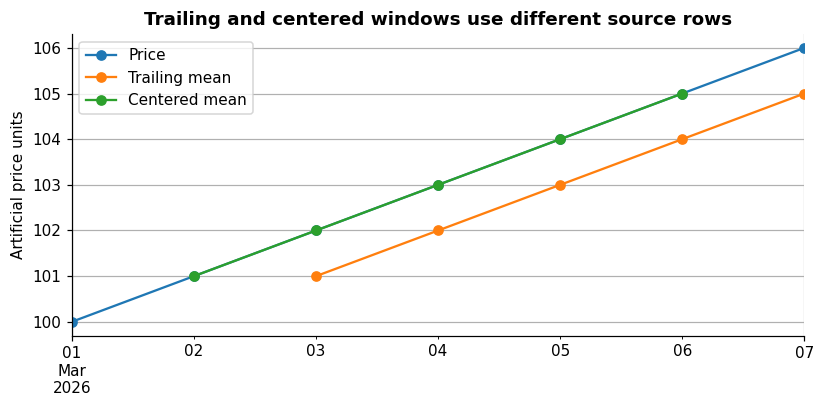

In [15]:
window_demo = pd.Series(
    [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0],
    index=pd.date_range("2026-03-01", periods=7, freq="D"),
    name="Price",
)
window_changed = window_demo.copy()
window_changed.iloc[4] = 140.0

window_comparison = pd.DataFrame(
    {
        "Price_original": window_demo,
        "Trailing_3_original": window_demo.rolling(3, center=False).mean(),
        "Centered_3_original": window_demo.rolling(3, center=True).mean(),
        "Price_changed": window_changed,
        "Trailing_3_changed": window_changed.rolling(3, center=False).mean(),
        "Centered_3_changed": window_changed.rolling(3, center=True).mean(),
    }
)
display(window_comparison.round(4))

comparison_date = window_demo.index[3]
effect_table = pd.DataFrame(
    {
        "Original": [window_comparison.loc[comparison_date, "Trailing_3_original"], window_comparison.loc[comparison_date, "Centered_3_original"]],
        "After_later_price_change": [window_comparison.loc[comparison_date, "Trailing_3_changed"], window_comparison.loc[comparison_date, "Centered_3_changed"]],
    },
    index=["Trailing mean at comparison date", "Centered mean at comparison date"],
)
effect_table["Changed"] = ~np.isclose(effect_table["Original"], effect_table["After_later_price_change"])
display(effect_table)

ax = window_comparison[["Price_original", "Trailing_3_original", "Centered_3_original"]].plot(marker="o")
ax.set_ylabel("Artificial price units")
ax.set_title("Trailing and centered windows use different source rows")
ax.legend(["Price", "Trailing mean", "Centered mean"])
plt.tight_layout()
plt.show()

assert not effect_table.loc["Trailing mean at comparison date", "Changed"]
assert effect_table.loc["Centered mean at comparison date", "Changed"]

### Interpret the output


Changing the price one row after the comparison date leaves the trailing mean unchanged but changes the centered mean. This is direct evidence that the centered feature at that label uses a later observation. A smooth curve is not a defense against an invalid information boundary.


### Discussion questions

1. Which three prices enter each mean at the comparison date?
2. When could centered smoothing be acceptable for descriptive analysis?
3. Why is a visually smoother feature not necessarily a valid trading input?
4. What prefix-based test could detect dependence on later rows?

### Evidence to preserve

Save both input paths, the comparison table, effect table, assertions, figure, and the exact future source row used by the centered window.

### First diagnostic action

When a feature may depend on later values, recompute it on a historical prefix and compare the overlapping result with the full-data calculation.

## Issue 15 — When does preprocessing use unavailable rows?


A valid trailing feature can become invalid when preprocessing parameters are estimated with later observations. Standardizing with the mean and standard deviation of the full dataset lets the earlier transformed rows depend on the later sample distribution.

The example separates a development segment from a later segment. It compares parameters fitted only on the development rows with parameters fitted on all rows. This illustrates the boundary; Week 5 will place preprocessing inside chronological model estimation.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [16]:
scaling_source = features["mom_5"].dropna().copy()
development_size = 55
development_values = scaling_source.iloc[:development_size]

development_mean = development_values.mean()
development_std = development_values.std(ddof=1)
full_mean = scaling_source.mean()
full_std = scaling_source.std(ddof=1)

features.loc[scaling_source.index, "mom_5_z_development_fit"] = (
    scaling_source - development_mean
) / development_std
features.loc[scaling_source.index, "mom_5_z_full_fit_invalid"] = (
    scaling_source - full_mean
) / full_std

parameter_table = pd.DataFrame(
    {
        "Fit_rows": [development_size, len(scaling_source)],
        "Mean": [development_mean, full_mean],
        "Standard_deviation": [development_std, full_std],
        "Permitted_for_development_rows": [True, False],
    },
    index=["Development-only fit", "Full-data fit"],
)
display(parameter_table.round(6))
display(
    features[["mom_5", "mom_5_z_development_fit", "mom_5_z_full_fit_invalid"]]
    .loc[scaling_source.index[:5]]
    .round(6)
)

parameter_difference = pd.Series(
    {
        "absolute_mean_difference": abs(development_mean - full_mean),
        "absolute_std_difference": abs(development_std - full_std),
        "maximum_transformed_difference_on_development_rows": (
            features.loc[development_values.index, "mom_5_z_development_fit"]
            - features.loc[development_values.index, "mom_5_z_full_fit_invalid"]
        ).abs().max(),
    },
    name="Difference",
)
display(parameter_difference.rename_axis("Check").to_frame())
assert parameter_difference["maximum_transformed_difference_on_development_rows"] > 0

,Fit_rows,Mean,Standard_deviation,Permitted_for_development_rows
Development-only fit,55,0.017468,0.030663,True
Full-data fit,85,0.008758,0.031158,False


,mom_5,mom_5_z_development_fit,mom_5_z_full_fit_invalid
Artificial_Date,,,
2024-01-09,0.002037,-0.503246,-0.215691
2024-01-10,-0.004585,-0.719197,-0.428215
2024-01-11,0.022046,0.149296,0.426498
2024-01-12,0.001847,-0.509438,-0.221784
2024-01-15,-0.008489,-0.846514,-0.553513


,Difference
Check,
absolute_mean_difference,0.008711
absolute_std_difference,0.000494
maximum_transformed_difference_on_development_rows,0.300219


### Interpret the output


The full-data and development-only parameters differ, so even the early transformed rows change. The momentum formula itself remains trailing; the invalidity enters through parameter estimation. A later model must fit preprocessing only on the rows permitted at that prediction time.


### Discussion questions

1. Which later rows influence the full-data mean?
2. Why can the raw feature be valid while its standardized version leaks?
3. What parameters must be saved for reproducibility?
4. How should rolling or expanding model updates refit preprocessing in Week 5?

### Evidence to preserve

Save the fit-period boundary, both parameter sets, transformed-row comparison, maximum difference, and a statement locating the leakage.

### First diagnostic action

When preprocessing results seem too stable or strong, locate exactly which rows were used to fit every scaler, imputer, selector, and threshold.

## Issue 16 — Should unavailable feature history become zero?


An unavailable feature and a valid feature value of zero have different meanings. The former means the required source history does not exist; the latter is a calculated result. Replacing early missing features with zero silently changes the financial rule.

The example compares a signal that preserves unavailable momentum with one that first fills it with zero. Week 3 does not choose a position for either signal; Week 4 will state how unavailable signals affect initial exposure.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Close,mom_5,Signal_preserving_missing_history,Signal_after_invalid_zero_fill
Artificial_Date,,,,
2024-01-02,99.072580,NaN,NaN,0.0
2024-01-03,99.378876,NaN,NaN,0.0
2024-01-04,97.162385,NaN,NaN,0.0
2024-01-05,98.823251,NaN,NaN,0.0
2024-01-08,99.603017,NaN,NaN,0.0
2024-01-09,99.274415,0.002037,1.0,1.0
2024-01-10,98.923269,-0.004585,0.0,0.0
2024-01-11,99.304463,0.022046,1.0,1.0
2024-01-12,99.005816,0.001847,1.0,1.0


,Missing_signal_values,Early_rows_labeled_cash
Preserve unavailable history,5,0
Fill feature with zero first,0,5


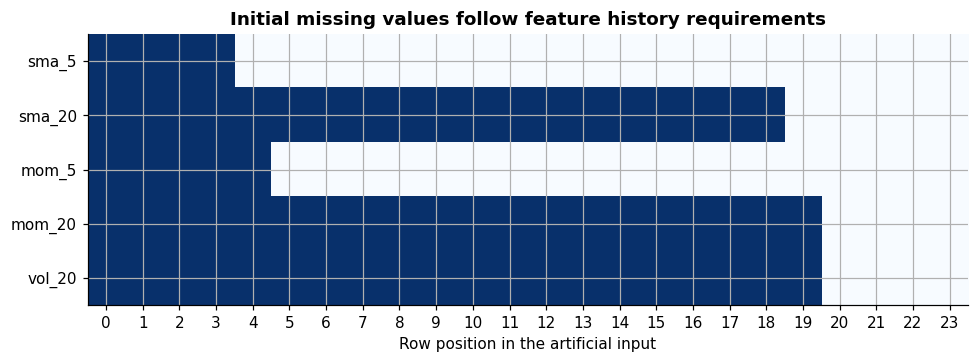

In [17]:
safe_signal_preview = pd.Series(
    np.where(
        features["mom_5"].isna(),
        np.nan,
        np.where(features["mom_5"] > 0, 1.0, 0.0),
    ),
    index=features.index,
    name="Signal_preserving_missing_history",
)
invalid_filled_preview = (features["mom_5"].fillna(0.0) > 0).astype(float).rename(
    "Signal_after_invalid_zero_fill"
)

missing_policy_table = pd.concat(
    [features["Close"], features["mom_5"], safe_signal_preview, invalid_filled_preview],
    axis=1,
).head(9)
display(missing_policy_table.round(6))

policy_counts = pd.DataFrame(
    {
        "Missing_signal_values": [safe_signal_preview.isna().sum(), invalid_filled_preview.isna().sum()],
        "Early_rows_labeled_cash": [0, int((invalid_filled_preview.iloc[:5] == 0).sum())],
    },
    index=["Preserve unavailable history", "Fill feature with zero first"],
)
display(policy_counts)

missing_matrix = features[["sma_5", "sma_20", "mom_5", "mom_20", "vol_20"]].head(24).isna().astype(int).T
fig, ax = plt.subplots(figsize=(9.0, 3.4))
ax.imshow(missing_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(np.arange(len(missing_matrix.index)), missing_matrix.index)
ax.set_xticks(np.arange(len(missing_matrix.columns)), [str(i) for i in range(len(missing_matrix.columns))])
ax.set_xlabel("Row position in the artificial input")
ax.set_title("Initial missing values follow feature history requirements")
plt.tight_layout()
plt.show()

assert safe_signal_preview.isna().sum() == 5
assert invalid_filled_preview.isna().sum() == 0

### Interpret the output


The invalid procedure converts five unavailable feature values into five observed zero signals. The heatmap shows that different features have different required histories. Missingness at the start is therefore expected evidence about feature construction, not a defect to erase automatically.


### Discussion questions

1. What does a genuine momentum value of zero mean?
2. Why is that meaning different from unavailable history?
3. Which feature in the heatmap requires the longest history?
4. What initial-position rule must Week 4 state separately?

### Evidence to preserve

Save both signal previews, counts, missingness figure, source-history explanation, and any later initialization decision as separate evidence.

### First diagnostic action

When early signals appear before the feature's first valid date, search for `fillna`, default Boolean conversion, and shortened `min_periods`.

## Issue 17 — How is a separately published value aligned?


A variable can describe an earlier period but remain unavailable until its publication time. Joining on the period-end label would place the value into decisions that occurred before release. For a point-in-time decision, align to the most recent release whose publication time is no later than the decision time.

`pandas.merge_asof` requires sorted keys. A backward search implements the stated no-later-than rule in this artificial example.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,decision_time
0,2026-04-02 16:05:00
1,2026-04-03 07:30:00
2,2026-04-03 16:05:00
3,2026-04-06 16:05:00


,period_end,publication_time,indicator_value
0,2026-03-31,2026-04-03 08:00:00,1.2


,decision_time,period_end,publication_time,indicator_value,release_available
0,2026-04-02 16:05:00,NaT,NaT,NaN,False
1,2026-04-03 07:30:00,NaT,NaT,NaN,False
2,2026-04-03 16:05:00,2026-03-31,2026-04-03 08:00:00,1.2,True
3,2026-04-06 16:05:00,2026-03-31,2026-04-03 08:00:00,1.2,True


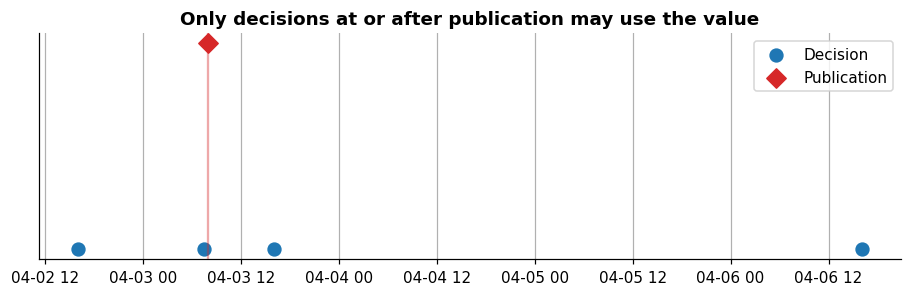

In [18]:
decisions = pd.DataFrame(
    {
        "decision_time": pd.to_datetime(
            [
                "2026-04-02 16:05", "2026-04-03 07:30",
                "2026-04-03 16:05", "2026-04-06 16:05",
            ]
        )
    }
).sort_values("decision_time")

releases = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-03-31"]),
        "publication_time": pd.to_datetime(["2026-04-03 08:00"]),
        "indicator_value": [1.20],
    }
).sort_values("publication_time")

aligned_release = pd.merge_asof(
    decisions,
    releases,
    left_on="decision_time",
    right_on="publication_time",
    direction="backward",
)
aligned_release["release_available"] = aligned_release["indicator_value"].notna()
display(decisions)
display(releases)
display(aligned_release)

fig, ax = plt.subplots(figsize=(8.4, 2.8))
ax.scatter(decisions["decision_time"], np.zeros(len(decisions)), marker="o", s=70, label="Decision")
ax.scatter(releases["publication_time"], [0.12], marker="D", s=80, color="tab:red", label="Publication")
ax.axvline(releases["publication_time"].iloc[0], color="tab:red", alpha=0.4)
ax.set_yticks([])
ax.set_title("Only decisions at or after publication may use the value")
ax.legend()
plt.tight_layout()
plt.show()

matched = aligned_release["publication_time"].notna()
assert aligned_release.loc[:1, "indicator_value"].isna().all()
assert aligned_release.loc[2:, "indicator_value"].eq(1.20).all()
assert (aligned_release.loc[matched, "publication_time"] <= aligned_release.loc[matched, "decision_time"]).all()

### Interpret the output


The April 2 and April 3 07:30 decisions remain unmatched. The two later decisions receive 1.20 because publication occurred at 08:00. The period-end date does not control availability. The figure makes the release boundary visible without implying a real publication schedule.


### Discussion questions

1. Why can the April 2 decision not use a value describing March 31?
2. What sorting requirement must be satisfied before `merge_asof`?
3. When would `allow_exact_matches=False` be appropriate?
4. What provider evidence would be needed for a real release timestamp?

### Evidence to preserve

Save both input tables, join settings, aligned output, no-future assertion, figure, and one sentence distinguishing period end from publication time.

### First diagnostic action

When a value appears too early, display decision time, period end, publication time, join direction, exact-match rule, and sort order.

## Issue 18 — Which historical release version was available?


Some published values are revised. A later corrected value may be appropriate for current analysis but was not available to an earlier historical decision. A point-in-time analysis must retain each release version rather than replace every historical observation with the latest value.

The artificial example publishes 1.20 and later revises it to 1.50. Backward alignment gives each decision the most recent release version available at that time.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [19]:
revision_decisions = pd.DataFrame(
    {
        "decision_time": pd.to_datetime(
            ["2026-04-03 16:05", "2026-04-08 16:05", "2026-04-13 16:05"]
        )
    }
).sort_values("decision_time")

release_versions = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-03-31", "2026-03-31"]),
        "publication_time": pd.to_datetime(["2026-04-03 08:00", "2026-04-10 08:00"]),
        "release_version": ["initial release", "revision"],
        "indicator_value": [1.20, 1.50],
    }
).sort_values("publication_time")

release_version_aligned = pd.merge_asof(
    revision_decisions,
    release_versions,
    left_on="decision_time",
    right_on="publication_time",
    direction="backward",
)
latest_value_backfill = release_version_aligned.copy()
latest_value_backfill["indicator_value"] = release_versions["indicator_value"].iloc[-1]
latest_value_backfill["release_version"] = "latest value copied backward — invalid for earlier decisions"

display(release_versions)
display(release_version_aligned)
display(
    pd.DataFrame(
        {
            "Point_in_time_value": release_version_aligned["indicator_value"].to_numpy(),
            "Invalid_latest_value_backfill": latest_value_backfill["indicator_value"].to_numpy(),
        },
        index=pd.DatetimeIndex(release_version_aligned["decision_time"], name="decision_time"),
    )
)

assert release_version_aligned["indicator_value"].tolist() == [1.20, 1.20, 1.50]
assert (release_version_aligned["publication_time"] <= release_version_aligned["decision_time"]).all()

,period_end,publication_time,release_version,indicator_value
0,2026-03-31,2026-04-03 08:00:00,initial release,1.2
1,2026-03-31,2026-04-10 08:00:00,revision,1.5


,decision_time,period_end,publication_time,release_version,indicator_value
0,2026-04-03 16:05:00,2026-03-31,2026-04-03 08:00:00,initial release,1.2
1,2026-04-08 16:05:00,2026-03-31,2026-04-03 08:00:00,initial release,1.2
2,2026-04-13 16:05:00,2026-03-31,2026-04-10 08:00:00,revision,1.5


,Point_in_time_value,Invalid_latest_value_backfill
decision_time,,
2026-04-03 16:05:00,1.2,1.5
2026-04-08 16:05:00,1.2,1.5
2026-04-13 16:05:00,1.5,1.5


### Interpret the output


The first two decisions receive the initial value because the revision did not yet exist. Only the last decision receives 1.50. Copying 1.50 backward changes the information set of earlier decisions and would invalidate a historical evaluation.


### Discussion questions

1. Which decisions legitimately use the revised value?
2. Why can a cleaner current dataset be historically inaccurate?
3. What identifiers should a provider supply for different release versions?
4. How would an undocumented revision affect reproducibility?

### Evidence to preserve

Save the release-version table, decision table, point-in-time alignment, invalid comparison, assertions, and a statement of which value each decision knew.

### First diagnostic action

When a historical feature seems inconsistent with old records, check retrieval date, release version, revision flag, and whether the latest value was copied backward.

## Issue 19 — How does a feature rule become a signal?


A signal is the output of a stated rule applied after all required features are available. For this artificial example, the rule returns 1 when five-session momentum is positive and 0 when it is nonpositive. It remains missing before momentum exists.

The rule output is recorded after the artificial close. It is not yet a position, trade, or return. Week 4 will apply the execution boundary and the required lag.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

,Count
Item,
observations,90
feature_available,85
signal_available,85
one_rule_outputs,52
zero_rule_outputs,33
missing_rule_outputs,5


,Close,mom_5,signal_at_close
Artificial_Date,,,
2024-01-02,99.072580,NaN,NaN
2024-01-03,99.378876,NaN,NaN
2024-01-04,97.162385,NaN,NaN
2024-01-05,98.823251,NaN,NaN
2024-01-08,99.603017,NaN,NaN
2024-01-09,99.274415,0.002037,1.0
2024-01-10,98.923269,-0.004585,0.0
2024-01-11,99.304463,0.022046,1.0
2024-01-12,99.005816,0.001847,1.0


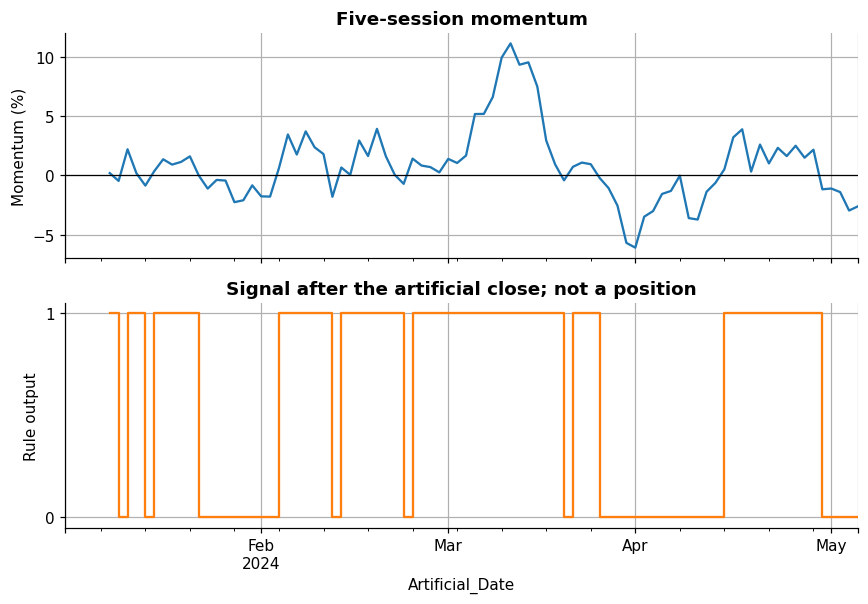

In [20]:
features["signal_at_close"] = np.where(
    features["mom_5"].isna(),
    np.nan,
    np.where(features["mom_5"] > 0, 1.0, 0.0),
)

signal_counts = pd.Series(
    {
        "observations": len(features),
        "feature_available": int(features["mom_5"].notna().sum()),
        "signal_available": int(features["signal_at_close"].notna().sum()),
        "one_rule_outputs": int(features["signal_at_close"].eq(1).sum()),
        "zero_rule_outputs": int(features["signal_at_close"].eq(0).sum()),
        "missing_rule_outputs": int(features["signal_at_close"].isna().sum()),
    },
    name="Count",
)
display(signal_counts.rename_axis("Item").to_frame())
display(features[["Close", "mom_5", "signal_at_close"]].head(10).round(6))

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.6), sharex=True)
(100 * features["mom_5"]).plot(ax=axes[0], color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Momentum (%)")
axes[0].set_title("Five-session momentum")
features["signal_at_close"].plot(ax=axes[1], drawstyle="steps-post", color="tab:orange")
axes[1].set_yticks([0, 1], ["0", "1"])
axes[1].set_ylabel("Rule output")
axes[1].set_title("Signal after the artificial close; not a position")
plt.tight_layout()
plt.show()

assert set(features["signal_at_close"].dropna().unique()).issubset({0.0, 1.0})
assert features["signal_at_close"].isna().equals(features["mom_5"].isna())
assert signal_counts["one_rule_outputs"] + signal_counts["zero_rule_outputs"] == signal_counts["signal_available"]

### Interpret the output


The available signals partition into 1 and 0, while the first five rows remain missing. A signal of 1 means only that the documented feature was positive at the stated calculation time. The figure deliberately labels the lower panel as a rule output rather than a holding.


### Discussion questions

1. What exact condition produces a signal of 1?
2. Why do the first five signal rows remain missing?
3. What execution assumption is still required before a signal can affect a position?
4. Which result would be an invalid Week 3 profitability claim?

### Evidence to preserve

Save the rule, threshold, missing policy, counts, first rows, figure, assertions, and a one-sentence interpretation of 0 and 1.

### First diagnostic action

When the signal counts do not reconcile, inspect missing momentum, comparison operators, threshold equality, data types, and any fills.

## Issue 20 — Can another student audit the feature and signal?


The Week 4 preparation must state every transformation and the information boundary without assigning a return. An audit table should connect source field, formula, lookback, first valid date, latest input, signal rule, decision time, earliest execution, and the claim that remains unsupported.

The example summarizes the objects created in this notebook and checks that all available signals correspond to available momentum values. It does not compare investment performance.


### Before running the example

Write one prediction about the output. Do not replace the prediction after seeing the result; add a revision underneath it.

In [21]:
week4_preparation_audit = pd.DataFrame(
    [
        ["Close", "Artificial closing price", "current row", features["Close"].first_valid_index(), "Close at t", "after artificial publication"],
        ["ret_1d", "Close[t] / Close[t-1] - 1", "one interval", features["ret_1d"].first_valid_index(), "Close at t", "after artificial publication"],
        ["mom_5", "Close[t] / Close[t-5] - 1", "five sessions", features["mom_5"].first_valid_index(), "Close at t", "after artificial publication"],
        ["vol_20", "sample sd of 20 returns times sqrt(252)", "twenty returns", features["vol_20"].first_valid_index(), "return ending at t", "after artificial publication"],
        ["signal_at_close", "1 if mom_5 > 0; 0 otherwise; missing if unavailable", "inherits mom_5", features["signal_at_close"].first_valid_index(), "mom_5 at t", "after artificial close"],
    ],
    columns=["Object", "Definition", "Lookback", "First_valid_date", "Latest_input", "Availability"],
).set_index("Object")

claim_boundary = pd.DataFrame(
    {
        "Evidence supports": [
            "reproducible artificial feature calculations",
            "documented availability and missing-history rules",
            "a deterministic binary rule output",
        ],
        "Evidence does not support": [
            "real-market data validity",
            "a fill, position, or backtest return",
            "profitability after costs or future performance",
        ],
    }
)
display(week4_preparation_audit)
display(claim_boundary)

week4_preparation_checks = pd.Series(
    {
        "feature_and_signal_missing_match": features["mom_5"].isna().equals(features["signal_at_close"].isna()),
        "available_signal_values_are_binary": set(features["signal_at_close"].dropna().unique()).issubset({0.0, 1.0}),
        "no_position_column_created": "position" not in features.columns,
        "no_strategy_return_column_created": "strategy_return" not in features.columns,
    },
    name="Passed",
)
display(week4_preparation_checks.rename_axis("Check").to_frame())
assert week4_preparation_checks.all()

,Definition,Lookback,First_valid_date,Latest_input,Availability
Object,,,,,
Close,Artificial closing price,current row,2024-01-02,Close at t,after artificial publication
ret_1d,Close[t] / Close[t-1] - 1,one interval,2024-01-03,Close at t,after artificial publication
mom_5,Close[t] / Close[t-5] - 1,five sessions,2024-01-09,Close at t,after artificial publication
vol_20,sample sd of 20 returns times sqrt(252),twenty returns,2024-01-30,return ending at t,after artificial publication
signal_at_close,1 if mom_5 > 0; 0 otherwise; missing if unavai...,inherits mom_5,2024-01-09,mom_5 at t,after artificial close


,Evidence supports,Evidence does not support
0,reproducible artificial feature calculations,real-market data validity
1,documented availability and missing-history rules,"a fill, position, or backtest return"
2,a deterministic binary rule output,profitability after costs or future performance


,Passed
Check,
feature_and_signal_missing_match,True
available_signal_values_are_binary,True
no_position_column_created,True
no_strategy_return_column_created,True


### Interpret the output


The preparation table preserves definitions and first valid dates. The final checks confirm that the Week 3 table contains neither a position nor a strategy return. Passing these checks establishes internal consistency under the stated artificial assumptions; it does not prove that the feature predicts anything.


### Discussion questions

1. Which Week 3 evidence must Week 4 preserve unchanged?
2. What new rule converts a signal into a position?
3. Why is the absence of a strategy-return column a useful scope check?
4. Which unresolved real-data fact could still invalidate the preparation for Week 4?

### Evidence to preserve

Save the preparation audit, claim-boundary table, passed checks, and one exact question that Week 4 must answer.

### First diagnostic action

When the preparation is incomplete, trace one date from original price observations through feature and signal time, stopping before any return attribution.

# Independent practice issues

These exercises use different artificial values and dates. Preserve your prediction before coding, complete input tables, calculations, visible checks, revisions, and unresolved questions. Starter cells intentionally do not contain solutions.

## Practice issue 1 — Complete an information boundary

An artificial closing price is observed on July 7 at 16:00 and becomes available at 16:02. A five-session momentum feature is calculated at 16:07 and the rule output is recorded at 16:08. The earliest permitted execution is July 8 at 09:00. Create an ordered table that includes observation, publication, feature, signal or decision, execution, and evaluation times.

Before coding, predict the first eligible return interval. Then verify chronological order and write one invalid interval that ended before the decision existed.

### Discussion questions

1. Which timestamp is a source fact and which is a classroom assumption?
2. Could observation and publication time be equal under another source?
3. Why can the July 7 close-to-close return not be assigned to this decision?
4. What evidence would be required before treating the July 8 execution time as fillable?

### Required evidence

Preserve the original facts, ordered table, Boolean checks, prediction, revision, valid interval statement, invalid interval statement, and every unresolved real-source field.

In [22]:
practice_1_events = pd.DataFrame(
    {
        "Event": ["Observation", "Publication", "Feature calculation", "Decision", "Earliest execution"],
        "Timestamp": pd.to_datetime(
            [
                "2026-07-07 16:00", "2026-07-07 16:02", "2026-07-07 16:07",
                "2026-07-07 16:08", "2026-07-08 09:00",
            ]
        ),
    }
)
display(practice_1_events)
print("Add an evaluation endpoint and write assertions for the complete chronological boundary.")

,Event,Timestamp
0,Observation,2026-07-07 16:00:00
1,Publication,2026-07-07 16:02:00
2,Feature calculation,2026-07-07 16:07:00
3,Decision,2026-07-07 16:08:00
4,Earliest execution,2026-07-08 09:00:00


Add an evaluation endpoint and write assertions for the complete chronological boundary.


## Practice issue 2 — Compare trailing features

Using the new artificial price and volume series below, calculate a four-price simple moving average, a four-span exponentially weighted mean with recorded settings, four-session momentum, and four-return rolling volatility. Also calculate a same-row range ratio and one-session volume change.

Predict the first valid row of every feature before coding. Produce a feature record with formulas, required source observations, units, latest inputs, first valid dates, and missing counts. Make one figure that compares the two smoothed price series and a second figure only if it materially clarifies another relationship.

### Discussion questions

1. Why do the four-price mean and four-session momentum start on different rows?
2. Which feature retains a price unit?
3. Which annualization settings require explicit disclosure?
4. Why does the exercise not establish which feature should enter a trading model?

### Required evidence

Preserve predictions, the original table, complete formulas, feature table, settings, first-valid-date table, assertions, figures, revisions, and one conclusion that the artificial calculation cannot support.

In [23]:
practice_2_data = pd.DataFrame(
    {
        "Open": [50.0, 51.0, 50.5, 52.0, 51.5, 53.0, 54.0, 53.5, 55.0, 56.0, 55.5, 57.0],
        "High": [51.0, 52.0, 51.5, 53.0, 52.5, 54.0, 55.0, 54.5, 56.0, 57.0, 56.5, 58.0],
        "Low": [49.5, 50.5, 50.0, 51.0, 51.0, 52.0, 53.0, 52.5, 54.0, 55.0, 54.5, 56.0],
        "Close": [50.5, 51.5, 51.0, 52.5, 52.0, 53.5, 54.5, 54.0, 55.5, 56.5, 56.0, 57.5],
        "Volume": [900, 940, 920, 980, 960, 1010, 1040, 1020, 1080, 1110, 1090, 1140],
    },
    index=pd.bdate_range("2026-07-01", periods=12),
)
practice_2_data.index.name = "Artificial_Date"
display(practice_2_data)
print("Create new feature columns and a separate feature-definition record; do not reuse the worked-example outputs as answers.")

,Open,High,Low,Close,Volume
Artificial_Date,,,,,
2026-07-01,50.0,51.0,49.5,50.5,900
2026-07-02,51.0,52.0,50.5,51.5,940
2026-07-03,50.5,51.5,50.0,51.0,920
2026-07-06,52.0,53.0,51.0,52.5,980
2026-07-07,51.5,52.5,51.0,52.0,960
2026-07-08,53.0,54.0,52.0,53.5,1010
2026-07-09,54.0,55.0,53.0,54.5,1040
2026-07-10,53.5,54.5,52.5,54.0,1020
2026-07-13,55.0,56.0,54.0,55.5,1080


Create new feature columns and a separate feature-definition record; do not reuse the worked-example outputs as answers.


## Practice issue 3 — Audit candidate features for leakage

The candidate table deliberately mixes valid, invalid, and unresolved proposals. For every row, identify the latest source observation, its availability time, whether the proposal is permitted at the stated decision, and the exact reason. Do not classify from the name alone.

Create at least one small calculation that demonstrates the defect of a centered window or a negative shift. Then rewrite every rejected candidate as a valid trailing or point-in-time calculation when possible.

### Discussion questions

1. Which candidate is a valid target but an invalid feature?
2. How can a valid raw feature become invalid during preprocessing?
3. What historical data are needed to evaluate a revised series correctly?
4. Which proposal remains unresolved until a provider supplies publication evidence?

### Required evidence

Preserve the candidate table, original prediction, completed audit, one demonstrated failure, repaired definitions, time-boundary reasoning, and a list of evidence still required.

In [24]:
practice_3_candidates = pd.DataFrame(
    {
        "Candidate": [
            "Close[t] / Close[t-5] - 1",
            "return[t+1] placed on row t",
            "five-row centered price mean",
            "trailing feature standardized with all rows",
            "reported value joined by period end",
            "reported value joined to last release no later than decision",
            "latest revised value copied to every historical date",
        ],
        "Proposed_role": ["feature", "feature", "feature", "feature", "feature", "feature", "feature"],
        "Student_label": ["", "", "", "", "", "", ""],
        "Latest_source_observation": ["", "", "", "", "", "", ""],
        "Reason": ["", "", "", "", "", "", ""],
    }
)
display(practice_3_candidates)
print("Complete the audit before implementing any repaired candidate.")

,Candidate,Proposed_role,Student_label,Latest_source_observation,Reason
0,Close[t] / Close[t-5] - 1,feature,,,
1,return[t+1] placed on row t,feature,,,
2,five-row centered price mean,feature,,,
3,trailing feature standardized with all rows,feature,,,
4,reported value joined by period end,feature,,,
5,reported value joined to last release no later...,feature,,,
6,latest revised value copied to every historica...,feature,,,


Complete the audit before implementing any repaired candidate.


## Practice issue 4 — Integrated information, feature, leakage, and signal case

This case combines the complete Week 3 workflow without asking for a backtest. All inputs are artificial. The price table represents artificial closing prices and volume for one artificial common stock. The dates are artificial session labels, not an exchange calendar. The separately published value describes an earlier period and becomes available only at its publication timestamp. No real provider, security, venue, timezone, or revision history is established.

### Part A — Document the inputs

1. Complete the record of when information becomes available for `Close`, `Volume`, every feature, and the separately published value.
2. Preserve the artificial source, field, unit, date, timestamp, and publication assumptions.
3. Mark every unsupported real-provider fact as `pending`.
4. State the latest input and earliest availability time of each proposed feature.

### Part B — Audit before feature construction

5. Verify date parsing, uniqueness, order, positive prices, nonnegative volume, and the expected missing first return.
6. Preserve the original data and create a separate audit table.
7. Explain why the artificial business-day labels are not an authoritative market calendar.
8. State why no conclusion may be transferred to a real asset.

### Part C — Construct and reconcile trailing features

9. Calculate five-session momentum, five- and ten-price moving averages, their relative gap, and ten-return rolling volatility.
10. Record formula, lookback, unit, `min_periods`, latest input, first valid date, and missing count for every feature.
11. Independently hand-check one momentum value and one moving average.
12. Produce a table and figure that preserve initial missing history.

### Part D — Audit unavailable information

13. Construct one deliberately centered moving average and one future-return column; label why neither is permitted as a time-$t$ feature.
14. Demonstrate that changing a later price changes a centered value but not the corresponding trailing value.
15. Align the published value backward to the decision timestamps and assert that no match comes from the future.

### Part E — Create and limit the signal

16. Define a rule that returns 1 only when five-session momentum is positive and the latest available published value is nonnegative; return 0 when both inputs exist but the condition fails; preserve missing when either input is unavailable.
17. Produce signal counts, a dated signal table, assertions, and a figure that labels the output as a signal rather than a position.
18. Write one conclusion supported by the artificial evidence and three conclusions not supported before Week 4 and later course stages.

### Discussion questions

1. Which input determines the earliest possible nonmissing signal?
2. Why is period end not the availability time of the published value?
3. Which passed checks establish calculation consistency, and which source facts remain unresolved?
4. What new assumptions must Week 4 add before any return can be assigned?

### Required evidence

Preserve all five input objects below, every record, audit, prediction, hand calculation, feature table, invalid-candidate demonstration, publication alignment, signal table, figure, assertion, revision, unresolved item, and conclusion boundary. Do not add a position, strategy return, wealth, cost, or performance measure.

In [25]:
practice_4_source_record = pd.DataFrame(
    {
        "Recorded_value": [
            "instructor-created artificial case",
            "Week 3 Practice issue 4",
            "embedded fixed table",
            "instructor-created course example; current repository access is private",
            "artificial common stock",
            "artificial closing price and reported volume",
            "artificial session labels; real calendar and timezone pending",
            "no real-market or performance claim permitted",
        ]
    },
    index=[
        "Provider", "Dataset", "Location", "Redistribution", "Security type",
        "Fields", "Timestamp meaning", "Claim boundary",
    ],
)

practice_4_prices = pd.DataFrame(
    {
        "Close": [
            80.0, 81.0, 80.5, 82.0, 83.0, 82.5, 84.0, 85.0, 84.5, 86.0,
            87.0, 86.5, 88.0, 89.0, 88.5, 90.0, 91.0, 90.5, 92.0, 93.0,
            92.5, 94.0, 95.0, 94.5, 96.0, 97.0, 96.5, 98.0, 99.0, 98.5,
        ],
        "Volume": [
            1000, 1020, 990, 1040, 1060, 1030, 1080, 1100, 1070, 1120,
            1140, 1110, 1160, 1180, 1150, 1200, 1220, 1190, 1240, 1260,
            1230, 1280, 1300, 1270, 1320, 1340, 1310, 1360, 1380, 1350,
        ],
    },
    index=pd.bdate_range("2026-05-01", periods=30),
)
practice_4_prices.index.name = "Artificial_Date"

practice_4_releases = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-04-30", "2026-05-15"]),
        "publication_time": pd.to_datetime(["2026-05-08 08:00", "2026-05-22 08:00"]),
        "published_value": [-0.25, 0.40],
    }
).sort_values("publication_time")

practice_4_decisions = pd.DataFrame(
    {
        "decision_time": practice_4_prices.index + pd.Timedelta(hours=16, minutes=5),
    }
).sort_values("decision_time")

practice_4_signal_rule = pd.DataFrame(
    {
        "Required_input": ["five-session momentum", "latest published value"],
        "Condition_for_1": ["> 0", ">= 0"],
        "Missing_policy": ["signal remains missing", "signal remains missing"],
    }
)

practice_4_inventory = pd.DataFrame(
    {
        "Object": ["Source record", "Price and volume table", "Release table", "Decision table", "Signal rule"],
        "Rows": [
            len(practice_4_source_record), len(practice_4_prices), len(practice_4_releases),
            len(practice_4_decisions), len(practice_4_signal_rule),
        ],
        "First student action": [
            "complete pending information",
            "audit before calculating",
            "verify publication order",
            "verify decision order",
            "record availability and missing-input behavior",
        ],
    }
)

display(practice_4_source_record)
display(practice_4_prices)
display(practice_4_releases)
display(practice_4_decisions.head())
display(practice_4_signal_rule)
display(practice_4_inventory)
print("Case inputs loaded. Preserve them before creating features or aligned values.")
print("Stop before positions, trades, returns, wealth, costs, or performance.")

,Recorded_value
Provider,instructor-created artificial case
Dataset,Week 3 Practice issue 4
Location,embedded fixed table
Redistribution,instructor-created course example; current rep...
Security type,artificial common stock
Fields,artificial closing price and reported volume
Timestamp meaning,artificial session labels; real calendar and t...
Claim boundary,no real-market or performance claim permitted


,Close,Volume
Artificial_Date,,
2026-05-01,80.0,1000
2026-05-04,81.0,1020
2026-05-05,80.5,990
2026-05-06,82.0,1040
2026-05-07,83.0,1060
2026-05-08,82.5,1030
2026-05-11,84.0,1080
2026-05-12,85.0,1100
2026-05-13,84.5,1070


,period_end,publication_time,published_value
0,2026-04-30,2026-05-08 08:00:00,-0.25
1,2026-05-15,2026-05-22 08:00:00,0.40


,decision_time
0,2026-05-01 16:05:00
1,2026-05-04 16:05:00
2,2026-05-05 16:05:00
3,2026-05-06 16:05:00
4,2026-05-07 16:05:00


,Required_input,Condition_for_1,Missing_policy
0,five-session momentum,> 0,signal remains missing
1,latest published value,>= 0,signal remains missing


,Object,Rows,First student action
0,Source record,8,complete pending information
1,Price and volume table,30,audit before calculating
2,Release table,2,verify publication order
3,Decision table,30,verify decision order
4,Signal rule,2,record availability and missing-input behavior


Case inputs loaded. Preserve them before creating features or aligned values.
Stop before positions, trades, returns, wealth, costs, or performance.


# Terminology reference

| Term | Meaning used in Week 3 |
|---|---|
| observation time | When the underlying event or source value occurs |
| publication time | When the value becomes available under the documented source process |
| feature | A documented input used in a stated analysis |
| technical indicator | A numerical summary constructed from market observations |
| lookback | The stated historical observations or interval used by a calculation |
| signal | The output of a stated rule after all required inputs are available |
| decision time | When the rule output is accepted for the next stated action |
| execution time | When a transaction may occur under an explicit assumption |
| evaluation time | When an outcome following execution can be observed |
| information leakage | Information unavailable at the historical decision entering the workflow |
| look-ahead bias | An evaluation using information unavailable at the relevant historical decision time |
| release version | The version of a published value available after a specific release or revision |
| simple moving average | Equal-weight mean of the observations in a stated trailing window |
| exponentially weighted mean | Mean with weights that decline according to a documented decay setting |
| trailing momentum | Price change between documented historical and current endpoints |
| rolling volatility | Dispersion of returns in a stated trailing window under a documented convention |

These descriptions govern the artificial lesson. Provider definitions, release records, market conventions, and the exact research design remain authoritative for real-data work.

# Troubleshooting reference

| Symptom | First check | Safe next action |
|---|---|---|
| Feature begins earlier than its required history | `window`, `min_periods`, shifts, and fills | List every required source row and restore unavailable values to missing |
| Feature starts later than expected | Count valid prices or returns inside each window | Display the first candidate window before changing settings |
| Momentum disagrees with hand calculation | Two price endpoints, their dates, field, and units | Recalculate the ratio from the displayed endpoints |
| Volatility is about 100 times too large | Decimal versus percentage inputs | Keep decimals in calculations and convert once for display |
| Centered feature looks unusually smooth | `center=True` and source dates | Recompute on a historical prefix and compare overlapping rows |
| Early standardized values change after adding later data | Preprocessing fit rows | Fit parameters only on the permitted development or training rows |
| Future target appears among features | Exact feature-column list | Remove the target and document when it becomes observable |
| Published value appears before release | Join key, direction, sorting, and exact-match rule | Align backward from decision time using publication time |
| Historical values all equal the latest revision | Release-version and retrieval fields | Restore the release version available at each decision |
| Early missing signal becomes zero | `fillna` and Boolean conversion | Preserve missing until the feature exists; define initial position later |
| Signal is multiplied by a same-row return | Scope and column audit | Stop; Week 4 must define execution and position lag first |
| Assertion fails | Exact input rows and stated boundary | Preserve the failure and diagnose the earliest incorrect transformation |

# Optional extensions and sources

## Optional extensions

These are not required for Week 3 completion:

- compare two documented exponentially weighted parameterizations and explain why their early values differ;
- add a three-state signal in `{-1, 0, 1}` while keeping short selling and performance outside Week 3;
- write a prefix test that recalculates every feature through selected historical dates;
- add an artificial release tolerance to `merge_asof` and document when an old value becomes too stale to use; and
- compare one provider's real timestamp and field definitions only after its use and redistribution conditions are approved.

## Official software references

- [`pandas.DataFrame.shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents row shifting.
- [`pandas.DataFrame.rolling`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) documents rolling windows, `min_periods`, and centered labels.
- [`pandas.DataFrame.ewm`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html) documents exponentially weighted calculations and their settings.
- [`pandas.merge_asof`](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html) documents sorted-key, backward, forward, nearest, tolerance, and exact-match behavior.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) documents fractional change rather than automatic percentage output.
- [`numpy.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) documents condition-based selection used by the signal rule.

## Financial research references

- Lo, A. W., Mamaysky, H., & Wang, J. (2000). [Foundations of Technical Analysis: Computational Algorithms, Statistical Inference, and Empirical Implementation](https://doi.org/10.1111/0022-1082.00265). *The Journal of Finance, 55*(4), 1705–1765.
- Jegadeesh, N., & Titman, S. (1993). [Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x). *The Journal of Finance, 48*(1), 65–91.

Lo, Mamaysky, and Wang support the established academic use of technical analysis and systematic empirical evaluation of technical patterns. The Week 3 moving averages and rule are simpler classroom calculations and do not reproduce that paper's pattern-recognition method or evidence. Jegadeesh and Titman support established academic study of past-return momentum, but their assets, formation periods, holding periods, portfolio construction, and evidence are not the five-session artificial feature used here. Official software documentation supports implementation behavior; it does not establish the financial validity, publication time, or predictive value of a dataset.

# Completion evidence

## Required submission

Submit this completed notebook or an exported report containing:

1. the environment-version table and completed records of when information becomes available;
2. every worked-example cell with its visible table or figure and passed checks;
3. at least one written response selected from the discussion questions for each of Issues 1–20, plus any additional responses designated during class;
4. predictions, calculations, revisions, and preserved evidence for Practice issues 1–4;
5. a feature dictionary stating financial meaning, formula, input, lookback, unit, latest source value, availability time, first valid date, and failure condition;
6. a leakage audit covering future targets, shifts, centered windows, preprocessing, publication joins, and revisions;
7. the publication-time alignment and Week 4 preparation table; and
8. one conclusion supported by the artificial evidence and three conclusions it cannot support.

## Completion conditions

The Week 3 work is complete when another student can:

- identify every observation entering each feature and state when it became available;
- reproduce every indicator and first valid date from the documented settings;
- separate a financial question, feature, future target, signal, position, and evaluation outcome;
- demonstrate at least one future-information failure and explain its repair;
- align a separately published value without using a future release or later revision;
- recreate the signal while preserving unavailable history; and
- explain why Week 3 contains no evidence of execution, trading performance, profitability after costs, or future results.

The timing, feature, leakage, and signal evidence begins the documentation required by the [Report 1 criteria](../10/week10_main.md). It does not change report weights or add a grading criterion.

## Exit evidence

Complete these statements:

```text
The financial question behind my feature is ______.
The latest source value used is ______ and it becomes available at ______.
The feature's first valid date is ______ because ______.
One leakage mechanism I demonstrated is ______.
My signal means ______, but it is not yet ______.
Week 4 must add ______ before any return can be attributed.
```

A correctly calculated technical indicator describes the stated historical inputs and convention. It does not establish predictability, an executable trade, profitability after costs, or future investment performance.